### Importar el Dataset

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('cybersecurity_threat_detection_logs.csv')

### Visualización del Dataset

In [10]:
print(df.head())

             timestamp      source_ip        dest_ip protocol   action  \
0  2024-05-01T00:00:00  192.168.1.125  192.168.1.124      TCP  blocked   
1  2024-07-18T00:00:00  192.168.1.201  192.168.1.201     ICMP  blocked   
2  2024-04-07T00:00:00  192.168.1.248   192.168.1.15     HTTP  allowed   
3  2024-10-26T00:00:00  192.168.1.236  192.168.1.219     HTTP  allowed   
4  2024-10-31T00:00:00  192.168.1.221   192.168.1.61     ICMP  allowed   

  threat_label     log_type  bytes_transferred  \
0       benign     firewall              10889   
1       benign  application              36522   
2       benign  application              20652   
3       benign  application               5350   
4       benign  application              40691   

                                          user_agent request_path  
0                              Nmap Scripting Engine            /  
1                              Nmap Scripting Engine            /  
2  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl.

In [17]:
# Tipos de peligros
print(df["threat_label"].unique())

['benign' 'suspicious' 'malicious']


In [18]:
# contar malicious y suspicious
print(df['threat_label'].value_counts()[['malicious', 'suspicious']])

threat_label
malicious     121506
suspicious    360883
Name: count, dtype: int64


### Analisis de los Logs

In [20]:
# Contar malicious y suspicious
print("Threat Labels")
print(df['threat_label'].value_counts())
print("\nSolo malicious + suspicious:",
      df['threat_label'].isin(['malicious', 'suspicious']).sum())

# Contar allowed vs blocked
print("\nActions (allowed vs blocked)")
print(df['action'].value_counts())

# IPs más activas
print("\nTop 10 IPs fuente más activas")
print(df['source_ip'].value_counts().head(10))

# User agents sospechosos (Nmap)
print("\nRegistros con Nmap en user_agent")
nmap = df[df['user_agent'].str.contains('Nmap', case=False, na=False)]
print(f"Total: {len(nmap)}")
print(nmap[['timestamp', 'source_ip', 'action', 'threat_label', 'user_agent']].head(10))

# Peticiones a /login
print("\nPeticiones a /login")
login = df[df['request_path'].str.contains('/login', case=False, na=False)]
print(f"Total: {len(login)}")
print(login[['timestamp', 'source_ip', 'action', 'threat_label']].head(10))


Threat Labels
threat_label
benign        5517611
suspicious     360883
malicious      121506
Name: count, dtype: int64

Solo malicious + suspicious: 482389

Actions (allowed vs blocked)
action
allowed    3000646
blocked    2999354
Name: count, dtype: int64

Top 10 IPs fuente más activas
source_ip
59.211.9.207       18295
109.106.120.222    18273
88.72.40.56        18252
185.225.185.68     18239
122.63.201.122     18229
229.140.23.152     18203
44.137.187.63      18202
114.207.221.220    18193
61.72.172.125      18193
166.19.156.163     18178
Name: count, dtype: int64

Registros con Nmap en user_agent
Total: 1199655
              timestamp       source_ip   action threat_label  \
0   2024-05-01T00:00:00   192.168.1.125  blocked       benign   
1   2024-07-18T00:00:00   192.168.1.201  blocked       benign   
11  2024-05-21T00:00:00    192.168.1.86  blocked       benign   
14  2024-06-30T00:00:00    88.29.76.112  allowed       benign   
17  2024-06-17T00:00:00    192.168.1.18  blocked    

#### Detección de posibles ataques o comportamientos anómalos

El análisis del campo threat_label muestra la presencia de eventos potencialmente maliciosos:

- benign: 5,517,611
- suspicious: 360,883
- malicious: 121,506

Total eventos sospechosos o maliciosos:

suspicious + malicious = 482,389 eventos

Esto representa una cantidad significativa de actividad potencialmente peligrosa dentro del sistema. Además, se observa un número elevado de registros con el user agent Nmap Scripting Engine, con un total de:

1,199,655 eventos

También se detectan múltiples accesos al endpoint:

/login → 640,790 peticiones

Un volumen elevado de accesos al login puede indicar intentos de:

- fuerza bruta
- credential stuffing
- enumeración de usuarios

Por tanto, existe evidencia clara de actividad sospechosa y potencialmente maliciosa en el sistema.

#### Identificación de patrones sospechosos en red

El análisis de acciones permitidas y bloqueadas muestra:

- allowed: 3,000,646
- blocked: 2,999,354

Existe una distribución prácticamente equilibrada entre tráfico permitido y bloqueado, lo que sugiere que el firewall está filtrando una gran cantidad de tráfico potencialmente peligroso.

Las IPs más activas son:

- 59.211.9.207 → 18,295 eventos
- 109.106.120.222 → 18,273 eventos
- 88.72.40.56 → 18,252 eventos
- 185.225.185.68 → 18,239 eventos
- 122.63.201.122 → 18,229 eventos

Estas direcciones IP generan un volumen elevado de tráfico, lo que puede indicar:

- escaneo automatizado
- bots
- intentos de ataque distribuidos
- actividad de reconocimiento

Además, la presencia masiva de eventos con Nmap refuerza la hipótesis de un escaneo de red a gran escala, probablemente automatizado y distribuido entre múltiples IPs. El alto número de peticiones al endpoint /login sugiere intentos repetidos de autenticación, lo que es consistente con un posible ataque de fuerza bruta.

#### Evaluar la utilidad del sistema de logging

El sistema de logs es bastante útil para seguridad, ya que registra información clave como IPs, protocolos, acciones (allowed/blocked), tipo de amenaza, user agent y rutas de acceso.

Esto permite:

Detectar escaneos de red (Nmap con ~1.2M eventos)
Identificar IPs con comportamiento sospechoso (muchas conexiones repetidas)
Detectar posibles ataques a /login (640.790 peticiones)
Diferenciar tráfico normal vs. malicioso (482.389 eventos suspicious/malicious)
Analizar tráfico bloqueado por el sistema de seguridad

Como limitación, el timestamp es poco preciso (solo fecha) y falta información más detallada de autenticación, lo que limitaría análisis más profundos.


### Gráficos


#### Eventos por protocolo

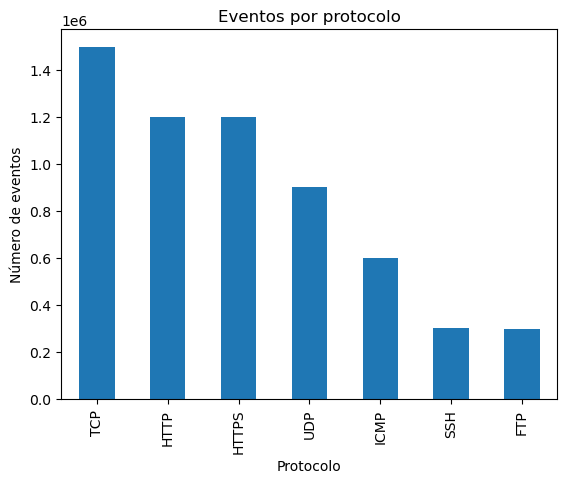

In [23]:
df['protocol'].value_counts().plot(kind='bar')
plt.title("Eventos por protocolo")
plt.xlabel("Protocolo")
plt.ylabel("Número de eventos")
plt.show()

#### Top Ips mas activas

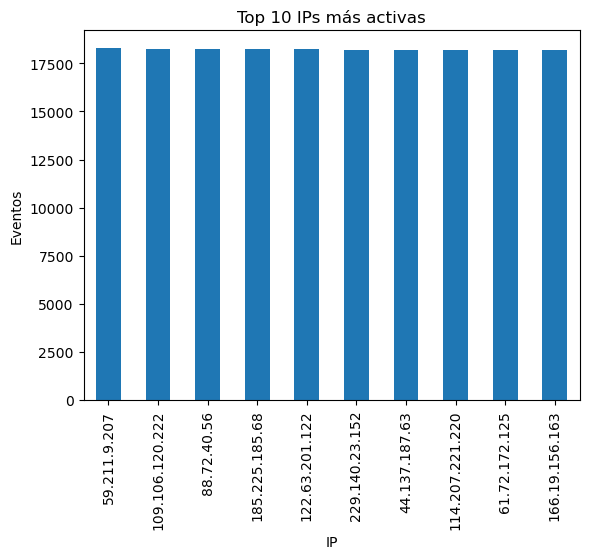

In [24]:
df['source_ip'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 IPs más activas")
plt.xlabel("IP")
plt.ylabel("Eventos")
plt.show()

#### Allowed vs Bloqued

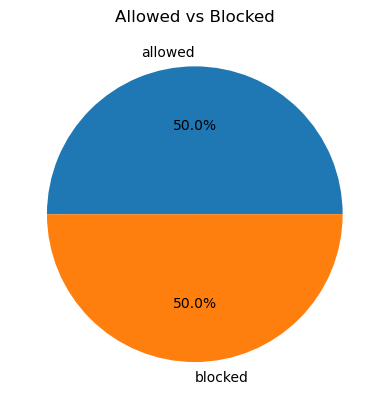

In [25]:
df['action'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Allowed vs Blocked")
plt.ylabel("")
plt.show()

#### Evolución Temporal

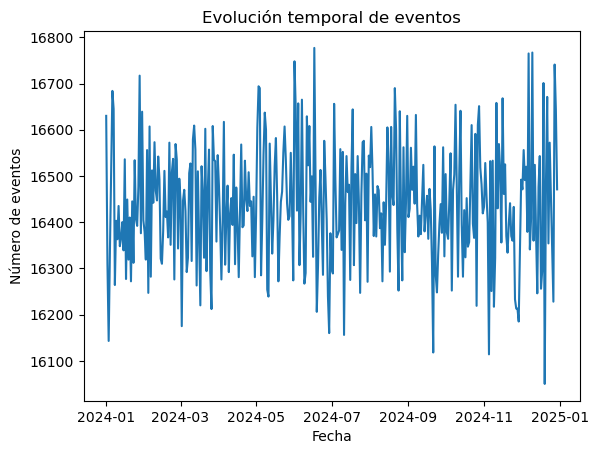

In [26]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.groupby(df['timestamp'].dt.date).size().plot()
plt.title("Evolución temporal de eventos")
plt.xlabel("Fecha")
plt.ylabel("Número de eventos")
plt.show()

### Interpretación

#### ¿Que está ocurriendo en el sistema?

El sistema está recibiendo un volumen muy alto de tráfico automatizado y constante durante todo el año 2024. El tráfico es muy uniforme (~16.000 eventos/día), lo que indica que no son usuarios humanos, sino bots funcionando de forma continua.

Los protocolos más usados (TCP, HTTP, ICMP) muestran actividad típica de escaneo y ataques automatizados

#### ¿Hay evidencia?

Sí, hay evidencia clara de ataque. Se observan varios tipos:

- Escaneo de red (TCP e ICMP muy elevados)
- Ataques distribuidos (botnet) por múltiples IPs con el mismo volumen de tráfico
- Posible fuerza bruta en SSH y FTP
- Ataques web dirigidos a HTTP/HTTPS
- Tráfico malicioso persistente durante todo el año

Además, el 50% de tráfico bloqueado indica que el firewall está filtrando una gran cantidad de actividad sospechosa, aunque no toda.

#### Conclusiones

Las conclusiones se basan en:

- Uso intensivo de protocolos asociados a ataques (TCP, ICMP, SSH, FTP)
- IPs con comportamiento uniforme (~18.000 eventos cada una), típico de botnets
- Distribución constante del tráfico sin variaciones humanas
- Alto porcentaje de tráfico bloqueado (50%)
- Actividad continua sin picos ni patrones naturales